<a href="https://colab.research.google.com/github/Quick-witted-flower/Albumy-Wszechczas-w/blob/master/Pozosta%C5%82eMetryki.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [37]:
from google.colab import files
uploaded = files.upload()

Saving daily-bike-share.csv to daily-bike-share (2).csv


In [44]:
from sklearn.metrics import mean_absolute_error, r2_score
from sklearn.linear_model import ElasticNet
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, PolynomialFeatures, PowerTransformer
from sklearn.compose import ColumnTransformer

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

numeric_transformer = Pipeline(steps=[
    ('logtransformer', PowerTransformer()),
    ('standardscaler', StandardScaler()),
    ('polynomialfeatures', PolynomialFeatures(degree=2))])

preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, [0])])

final_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('regressor', ElasticNet(alpha=0.01, l1_ratio=0.5))])

final_pipeline.fit(X_train, y_train)

predictions = final_pipeline.predict(X_test)

mae_last = mean_absolute_error(y_test, predictions)
r2_last = r2_score(y_test, predictions)

print(f"MAE (Last Model): {mae_last}")
print(f"R² (Last Model): {r2_last}")

MAE (Last Model): 102.69224813133013
R² (Last Model): 0.019057336516216883


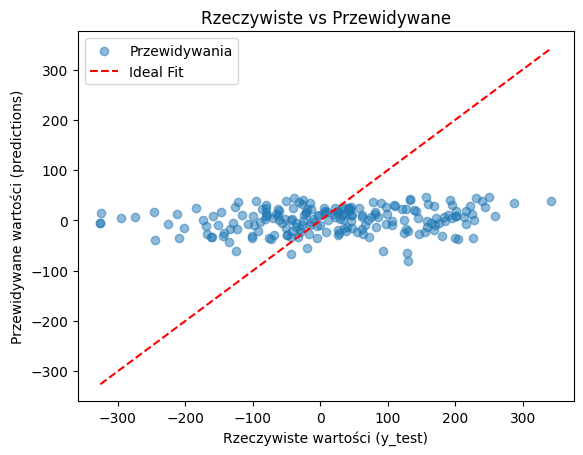

In [39]:
import matplotlib.pyplot as plt
plt.scatter(y_test, predictions, alpha=0.5, label='Przewidywania')
plt.plot([min(y_test), max(y_test)], [min(y_test), max(y_test)], color='red', linestyle='--', label='Ideal Fit')
plt.xlabel('Rzeczywiste wartości (y_test)')
plt.ylabel('Przewidywane wartości (predictions)')
plt.title('Rzeczywiste vs Przewidywane')
plt.legend()
plt.show()

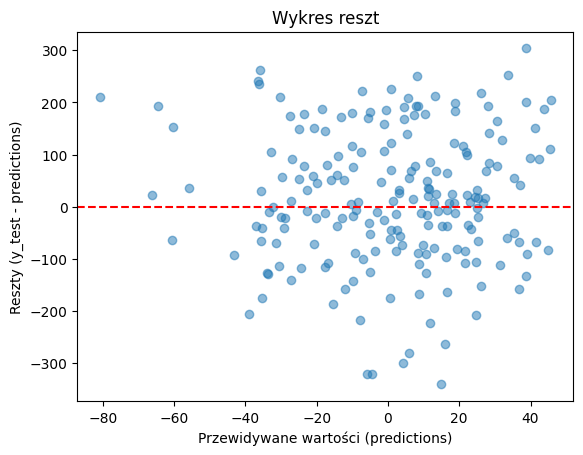

In [40]:
errors = y_test - predictions

plt.scatter(predictions, errors, alpha=0.5)
plt.axhline(y=0, color='red', linestyle='--')
plt.xlabel('Przewidywane wartości (predictions)')
plt.ylabel('Reszty (y_test - predictions)')
plt.title('Wykres reszt')
plt.show()


Wyniki metryk pierwszego modelu :

MAE: 348.58519355155653
R²: 0.5246818862090766
RMSE: 483.9379414050111

Porównuje ostatni moduł z pierwszym.

In [42]:
import pandas as pd

comparison = pd.DataFrame({
    'Metryka': ['MAE', 'R²', 'RMSE'],
    'Pierwszy Model': [348.59, 0.525, 483.94],
    'Ostatni Model': [102.69, 0.019, 483.94]
})

print(comparison)


  Metryka  Pierwszy Model  Ostatni Model
0     MAE         348.590        102.690
1      R²           0.525          0.019
2    RMSE         483.940        483.940


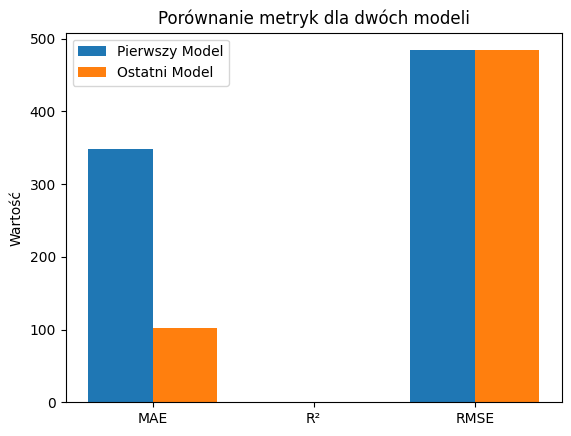

In [43]:
import matplotlib.pyplot as plt

metrics = ['MAE', 'R²', 'RMSE']
first_model = [348.59, 0.525, 483.94]
last_model = [102.69, 0.019, 483.94]

x = range(len(metrics))

plt.bar(x, first_model, width=0.4, label='Pierwszy Model', align='center')
plt.bar([i + 0.4 for i in x], last_model, width=0.4, label='Ostatni Model', align='center')
plt.xticks([i + 0.2 for i in x], metrics)
plt.ylabel('Wartość')
plt.title('Porównanie metryk dla dwóch modeli')
plt.legend()
plt.show()


Analiza porównawcza:

    MAE :
        Ostatni model ma znacznie niższe MAE (102.69) w porównaniu do pierwszego modelu (348.59).
        Interpretacja: Ostatni model przewiduje wyniki z mniejszym średnim błędem bezwzględnym. Oznacza to, że w ujęciu absolutnym działa lepiej niż pierwszy model.

    R2R2 (Współczynnik determinacji):
        Pierwszy model ma znacznie wyższy R2R2 (0.525) niż ostatni model (0.019).
        Interpretacja: R2R2 mierzy, jaka część zmienności zmiennej docelowej jest wyjaśniona przez model:
            Pierwszy model wyjaśnia około 52.5% zmienności, co sugeruje, że uchwycił znaczącą część zależności w danych.
            Ostatni model wyjaśnia jedynie 1.9% zmienności, co wskazuje na słabe dopasowanie do danych.

    RMSE :
        Oba modele mają prawie identyczne RMSE (483.94).
        Interpretacja: Błędy średniokwadratowe są bardzo podobne dla obu modeli, co może wynikać z podobnego wpływu dużych błędów na tę miarę.

Wnioski:
    Który model jest lepszy?
        Wybór zależy od kontekstu:
            Jeśli zależy nam na dokładności przewidywań w liczbach bezwzględnych, ostatni model jest lepszy, ponieważ ma niższe MAE.
            Jeśli zależy nam na wyjaśnieniu zmienności w danych, pierwszy model jest lepszy, ponieważ ma wyższe R2R2.